## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 — Data Loading & Exploration

###  Load the CSV file using Pandas

In [11]:
df = pd.read_csv("D:\Coding\Data science\Housing-Price-Prediction\Housing.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\admin\AppData\Local\Temp\ipykernel_16088\4210061298.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Coding\Data science\Housing-Price-Prediction\Housing.csv")


###  Display the first 10 rows

In [12]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Checking number of rows and columns

In [14]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  545
Number of columns:  13


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.describe(include="object")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


### identifying target and features

In [15]:
target = df["price"]
features = df.drop(columns=["price"])

### Checking for missing values 

In [23]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Task 2 — Data Cleaning

### Handle missing values (fill or drop, whichever fits the column)
    - scince there are no missing values so need to fill or drop 


### Remove duplicate rows, if any

In [31]:
df.duplicated().sum()

np.int64(0)

###  Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

In [50]:
cat_cols = df.select_dtypes("object").columns
df_numeric = pd.get_dummies(df, columns=cat_cols, drop_first=True)

display(df_numeric.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# Task 3 — Model Building

### Split the data into training and test sets (80/20)

In [53]:
from sklearn.model_selection import train_test_split

X = df_numeric.drop("price", axis=1)
y = df_numeric["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Size of training dataset: ", X_train.shape)
print("Size of testing dataset: ", X_test.shape)

Size of training dataset:  (436, 13)
Size of testing dataset:  (109, 13)


### Training Linear Regression

In [57]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

###  Evaluate it using MAE, RMSE, and R² Score

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_absolute_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Mean Squared Error: ", lr_mae)
print("Root Mean Squared Error: ", lr_rmse)
print("R2 score: ", lr_r2)

Mean Squared Error:  970043.4039201637
Root Mean Squared Error:  984.9078149350647
R2 score:  0.6529242642153184


###  Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [65]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_absolute_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Mean Squared Error: ", rf_mae)
print("Root Mean Squared Error: ", rf_rmse)
print("R2 score: ", rf_r2)

Mean Squared Error:  1021546.0353211008
Root Mean Squared Error:  1010.7156055592992
R2 score:  0.611918531405699


# Task 4 — Visualization (Minimum 3 charts)


### Chart 1: Histogram showing the distribution of house prices

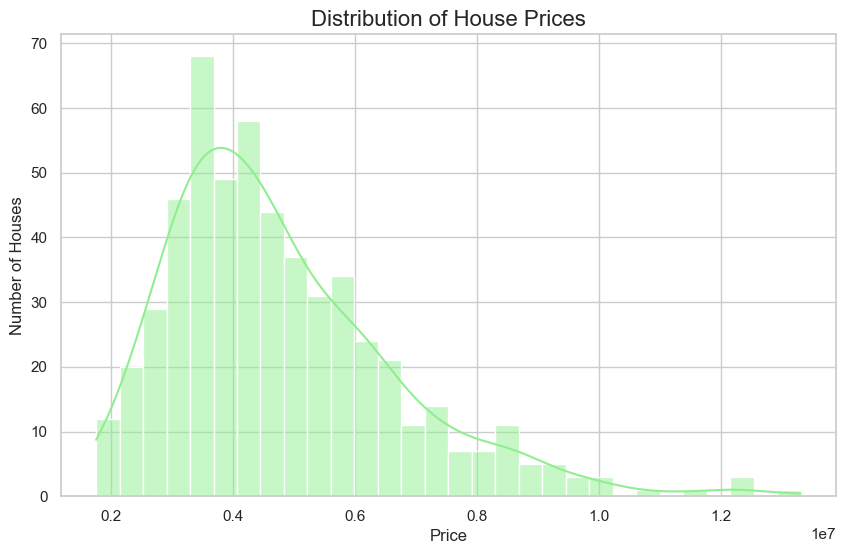

In [68]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_numeric["price"], bins=30, kde=True, color="lightgreen")
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.savefig('chart1_price_distribution.png', bbox_inches='tight')

plt.show()

### Chart 2: Correlation heatmap showing which features relate most strongly to price

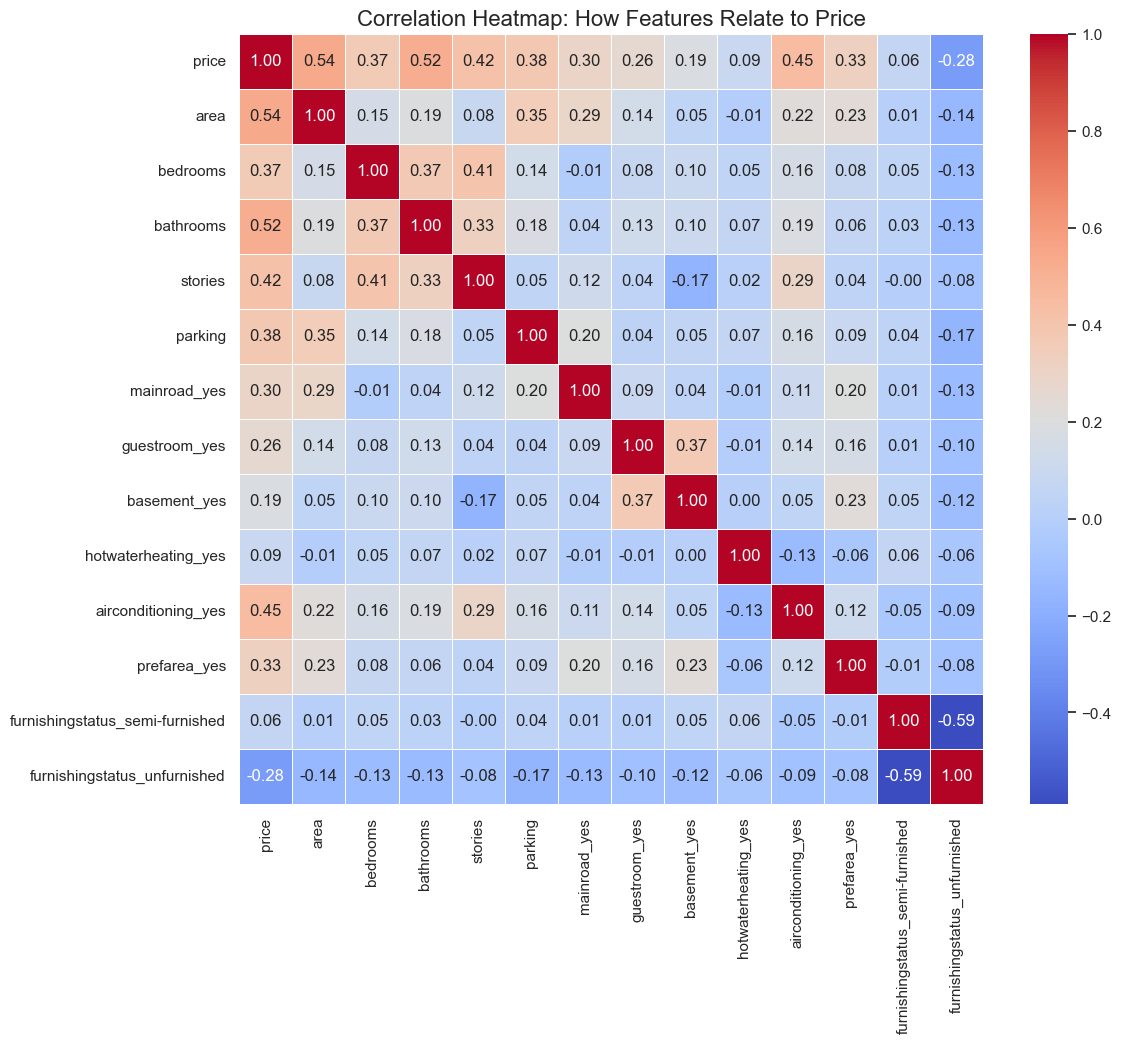

In [67]:
plt.figure(figsize=(12, 10))
corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: How Features Relate to Price', fontsize=16)
plt.savefig('chart2_correlation_heatmap.png', bbox_inches='tight')

plt.show()

###  Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)


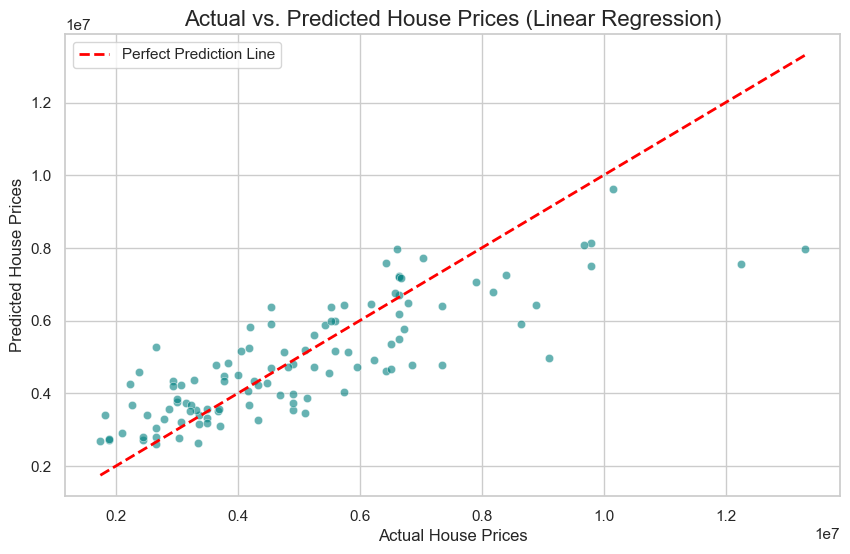

In [69]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred_lr, color='teal', alpha=0.6)

max_price = max(y_test.max(), y_pred_lr.max())
min_price = min(y_test.min(), y_pred_lr.min())
plt.plot([min_price, max_price], [min_price, max_price], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted House Prices (Linear Regression)', fontsize=16)
plt.xlabel('Actual House Prices', fontsize=12)
plt.ylabel('Predicted House Prices', fontsize=12)
plt.legend()

plt.savefig('chart3_actual_vs_predicted.png', bbox_inches='tight')

plt.show()

# Task 5 — Insights & Summary

    1 Which features influence house price the most?
        
        The features that most strongly drive up house prices are the number of bathrooms, the presence of air conditioning, and the total square footage (area). Conversely, an unfurnished status drops the value significantly.

    2 How accurate was your model (in plain terms)?
        
        The Linear Regression model was moderately accurate, explaining about 65.3% of the variations in house prices (R² = 0.65) and outperforming the Random Forest model.

    3 What surprised you in the data?
        
        I was surprised that the simpler Linear Regression model actually beat the more complex Random Forest model
        
    4 One recommendation for a real estate business based on your findings
        
        Real estate agents should strongly advise sellers to invest in air conditioning or stage their homes with furniture before listing, as the data shows these specific features yield massive returns on the final sale price.